In [122]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

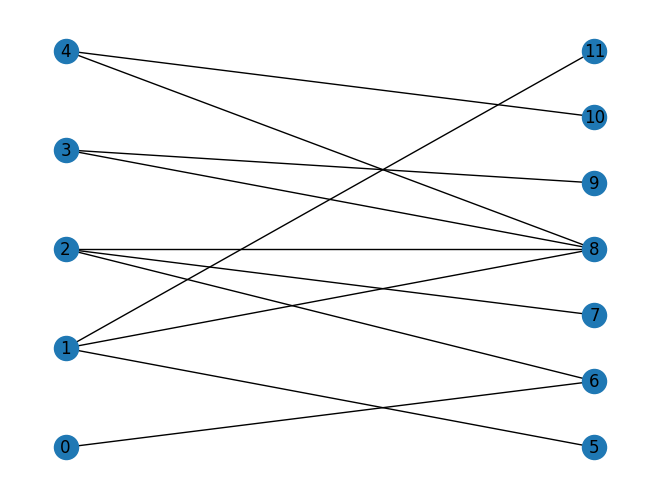

In [123]:
A = np.zeros((12,12))
A[0,6], A[1,8], A[2,7], A[2,8], A[2,6],A[3,8], A[3,9], A[4,8], A[4,10], A[5, 1] = 1,1,1,1,1,1,1,1,1,1
A[11,1]  = 1
A = A + A.T
G = nx.from_numpy_array(A, create_using=nx.Graph)
nx.draw(G, pos=nx.bipartite_layout(G))
labels = {n : f"{n}" for n in G.nodes()}  

nx.draw_networkx_labels(G, 
                        pos=nx.bipartite_layout(G),  # Mesma que o grafo.
                        labels=labels
                        ) 
plt.show()

[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[0 0 0 1 0 0 1]
 [0 0 1 1 0 0 0]
 [0 1 0 1 0 0 0]
 [1 1 1 0 1 0 1]
 [0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0]
 [1 0 0 1 0 0 0]]


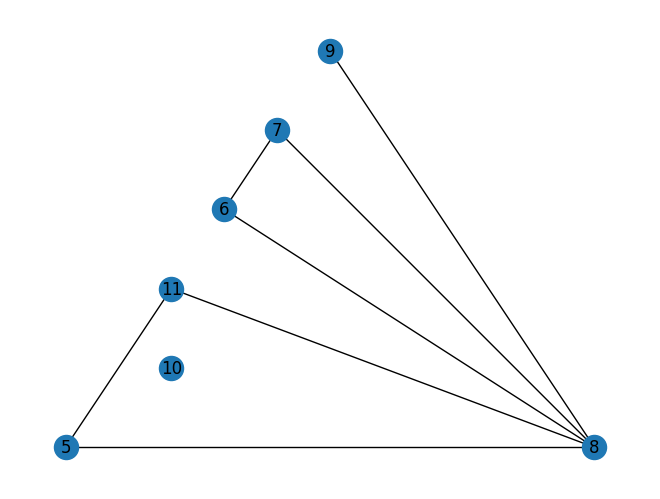

In [ ]:
# print(A)
B = A[5:, :4]
B_proj = B @ B.T
B_proj = (B_proj > 0).astype(np.uint8)
np.fill_diagonal(B_proj, 0)
print(B_proj)
G_proj = nx.from_numpy_array(B_proj, create_using=nx.Graph)

nx.draw(G_proj, pos=nx.planar_layout(G_proj))
labels = {n : f"{n + 5}" for n in G_proj.nodes()}  

nx.draw_networkx_labels(G_proj, 
                        pos=nx.planar_layout(G_proj),  # Mesma que o grafo.
                        labels=labels
                        ) 

plt.show()

{0: array([ 0.103421, -1.      ]), 1: array([-0.47223993, -0.04883952]), 2: array([0.47223993, 0.04883953]), 3: array([-0.10342099,  0.99999999])}
2.0


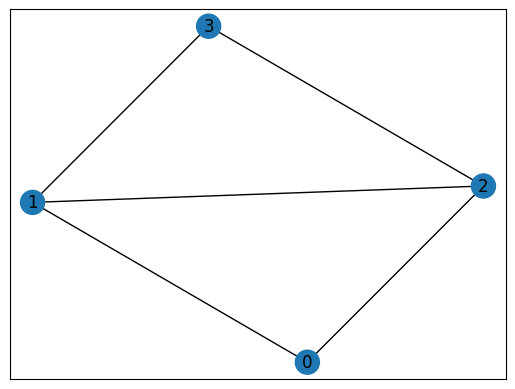

In [125]:
A = np.zeros((4,4))
A[0,1], A[1,0] = 1,1
A[0,2], A[2,0] = 1,1
A[2,1], A[1,2] = 1,1
A[3,1], A[1,3] = 1,1
A[3,2], A[2,3] = 1,1

G = nx.from_numpy_array(A, create_using=nx.Graph)

nx.display(G)
print(np.trace(A@A@A)/6)
plt.show()

{0: 0.02930494675966072, 1: 0.03207265385141658, 2: 0.05933459690677645, 3: 0.0825075467956423, 4: 0.10220499704586196, 5: 0.07551041463444744, 6: 0.1396947554634596, 7: 0.1508133709889058, 8: 0.16026269103584867, 9: 0.16829402651798056}


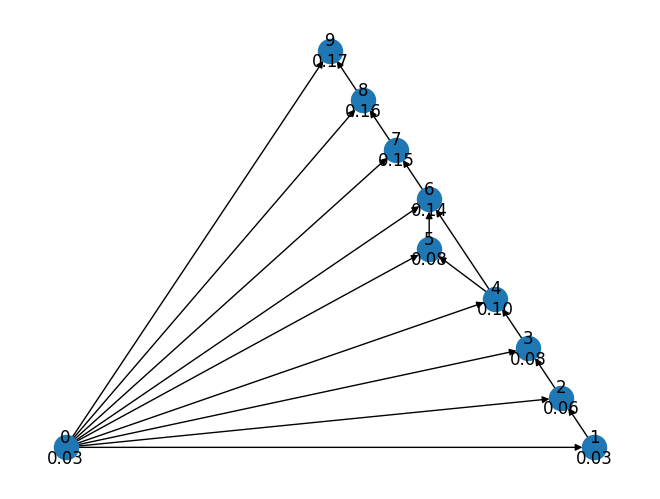

In [126]:
A = np.zeros((10,10))

for i in range(1,10):
    A[0,i] = 1

    if i != 1: A[i-1,i] = 1

A[4, 6] = 1

G = nx.from_numpy_array(A, create_using=nx.DiGraph)

pageRanks = nx.pagerank(G)
print(pageRanks)
nx.draw(G, pos=nx.planar_layout(G))

labels = {n : f"{n}\n{pageRanks[n]:.2f}" for n in G.nodes()}
nx.draw_networkx_labels(G, pos=nx.planar_layout(G), labels=labels)
plt.show()

num_componentes_conexas = 1
maior tamanho relativo = 30
grau médio = 3.066666666666667
variância dos garus = 0.1955555555555555


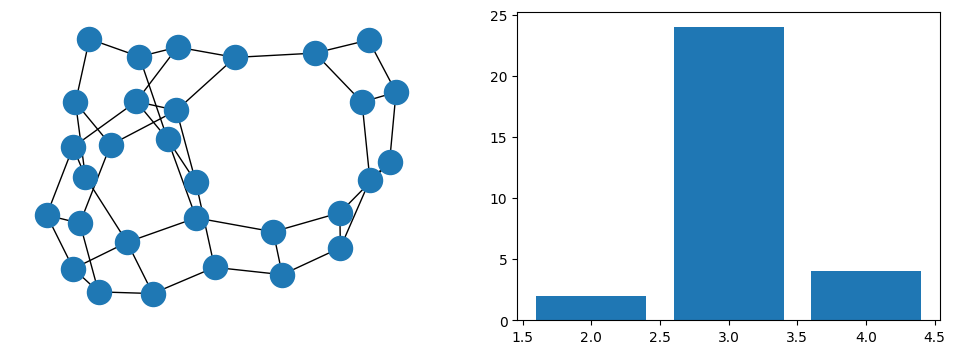

num_componentes_conexas = 1
maior tamanho relativo = 33
grau médio = 3.0303030303030303
variância dos garus = 6.089990817263543


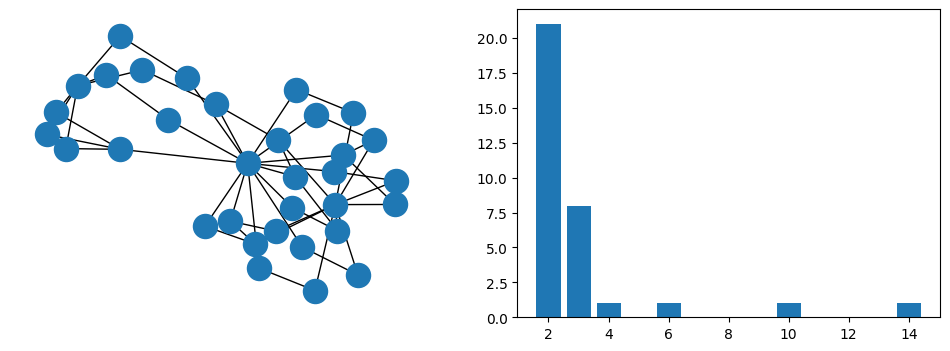

num_componentes_conexas = 1
maior tamanho relativo = 50
grau médio = 4.4
variância dos garus = 0.28


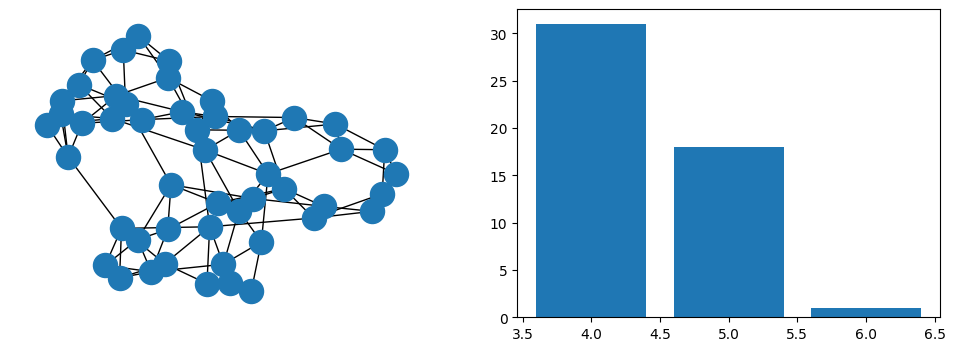

In [127]:
# edge_list = [
#     ('A', 'B'), ('B', 'C'), ('C', 'A'),  # Componente 1 (Central)
#     ('D', 'E'), ('E', 'F'), ('F', 'D'),  # Componente 2 (Menor)
#     ('G', 'H'), ('H', 'I'),              # Componente 3 (Linear)
#     ('J', 'J')                           # Componente 4 (Nó isolado com laço)
# ]


for i in [1,2,3]:
    edge_list = []
    with open(f'rede{i}.txt', 'r') as file:
        for l in file:
            if not l.strip():
                continue
            
            nodes = l.strip().split()
            if len(nodes) == 2:
                edge_list.append((nodes[0], nodes[1]))


    # 1. Criação do Grafo
    G = nx.Graph()
    G.add_edges_from(edge_list)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    nx.draw(G)

    # print(list(nx.connected_components(G))) 
    print(f"num_componentes_conexas = {len(list(nx.connected_components(G)))}")
    print(f"maior tamanho relativo = {len(max(list(nx.connected_components(G)), key=len))}")
    print(f"grau médio = {sum(g for n,g in G.degree) / G.number_of_nodes()}")
    print(f"variância dos garus = {np.var([g for n, g in G.degree])}")
    contagem_graus = Counter([g for n, g in G.degree])
    deg, cnt = zip(*contagem_graus.items())
    plt.subplot(1,2,2)
    plt.bar(deg, cnt, )
    plt.show()